In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
df = pd.read_csv('/Users/dakshsoni/Downloads/smartcart_customers.csv')

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [9]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [46]:
df.shape

(2240, 27)

In [47]:
#1 Handeling Missing Values
df["Income"] = df["Income"].fillna(df["Income"].median())


In [48]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                  0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
Age                     0
Customer_Tenure_days    0
Total_Spending          0
Total_Children          0
Living_With             0
dtype: int64

In [49]:
#2 Feature Engineering
#Age
df["Age"] = 2026 - df["Year_Birth"]
# Customer joining date
# Max date will be our tenure date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)
refrence_date = df["Dt_Customer"].max()
df["Customer_Tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days # to convert into days 

In [50]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [51]:
# Total Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [52]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [53]:
# Total Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [54]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace(
    {
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"}
)
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [55]:
# Marital Status
df["Living_With"] = df["Marital_Status"].replace(
    {
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"}
)
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [63]:
# Drop Unnecessary Columns 
cols = ["ID","Year_Birth","Marital_Status","Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df_clean = df.drop(columns = cols + spending_cols)

In [64]:
df_clean.shape

(2240, 15)

In [65]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


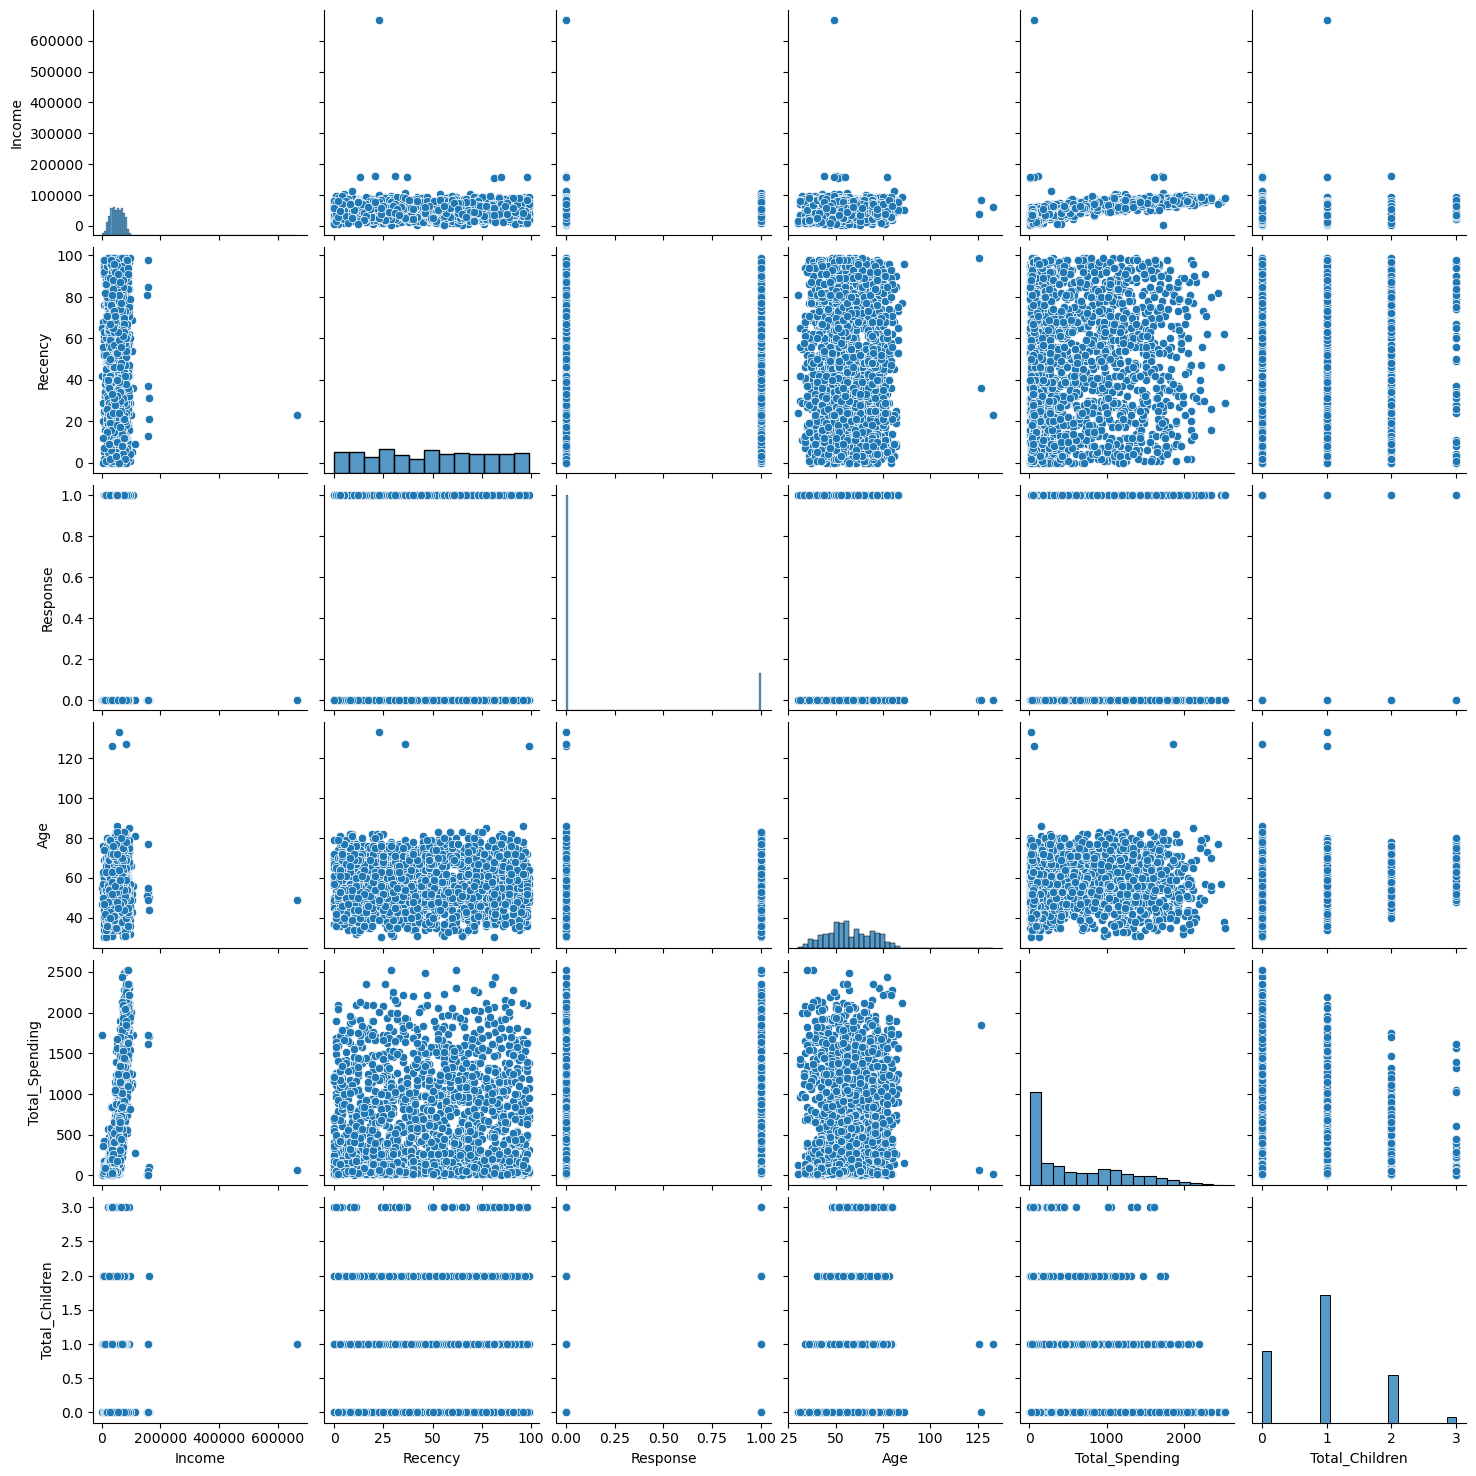

In [66]:
# Outliers 
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plots of some features- pair plots 
sns.pairplot(df_clean[cols])
# Remove the income with 600000 value, also remove age greater than 90

In [67]:
# Lets remove the outliers 

print("data size with outliers: ", len(df_clean))
df_clean = df_clean[ (df_clean["Age"]< 90) ]
df_clean = df_clean[ (df_clean["Income"] < 600_000)]
print("data size without the outliers: ", len(df_clean))

data size with outliers:  2240
data size without the outliers:  2236


In [69]:
# Heatmap
corr = df_clean.corr(numeric_only = True)

<Axes: >

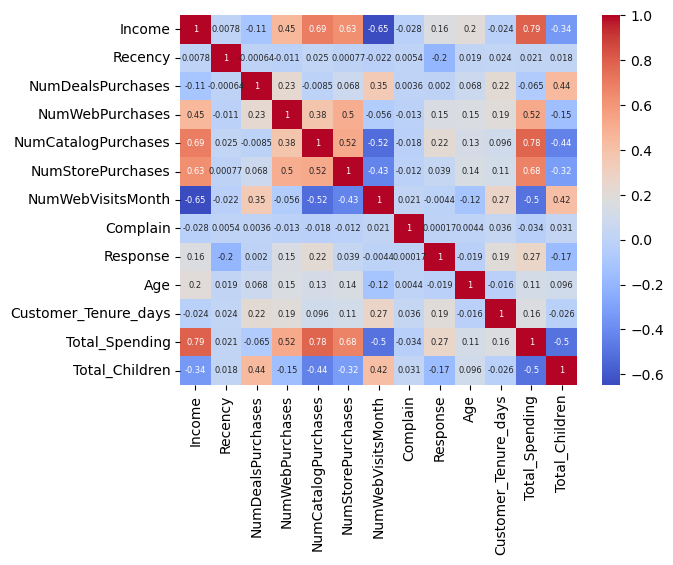

In [72]:
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size": 6},
    cmap = "coolwarm"
)

In [74]:
# Income -> Total-Spending = 0.79
# Total_Spending -> NumCatalogPurchase = 0.78
# Income -> NumCatalogPurchase = 0.63
# Income -> NumWebVisit = -0.65
# Income -> NumStorePurchase = 0.63
df_clean.shape

(2236, 15)

In [76]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [78]:
# Encoding 
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_clean[cat_cols])

In [80]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns = ohe.get_feature_names_out(cat_cols), index = df_clean.index)

In [81]:
enc_df.shape

(2236, 5)

In [84]:
df_encoded = pd.concat([df_clean.drop(columns = cat_cols), enc_df], axis = 1)

In [85]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [87]:
# Scaling
from sklearn.preprocessing import StandardScaler
X = df_encoded
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
# Visulize the data 

In [89]:
X_scaled.shape

(2236, 18)

In [97]:
# visulaize 
from sklearn.decomposition import PCA
pca = PCA(
    n_components = 3
)
X_pca = pca.fit_transform(X_scaled)

In [98]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

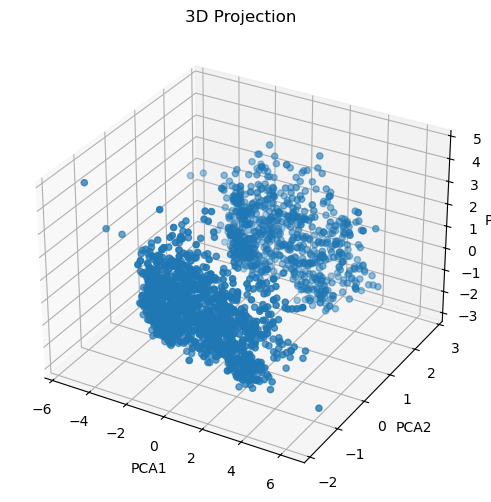

In [104]:
# plot
fig = plt.figure(figsize = (8, 6))

ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:, 2] )

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [105]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

#

# Clustering Analyze K value

In [112]:
# 1 Elbow Method
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [114]:
knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow

In [116]:
print("Best Value of K: ",optimal_k)

Best Value of K:  4


Text(0, 0.5, 'WCSS')

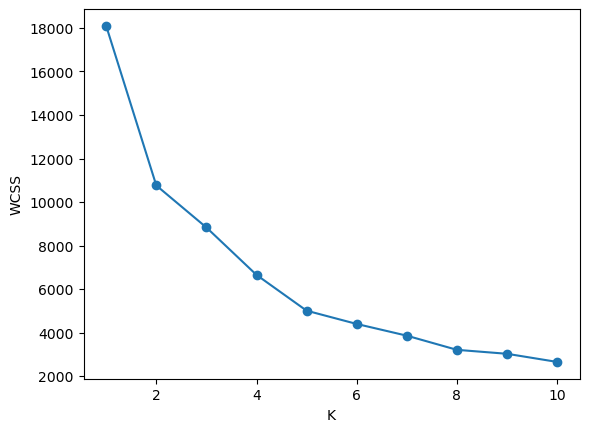

In [118]:
#Plot the K value
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette Score')

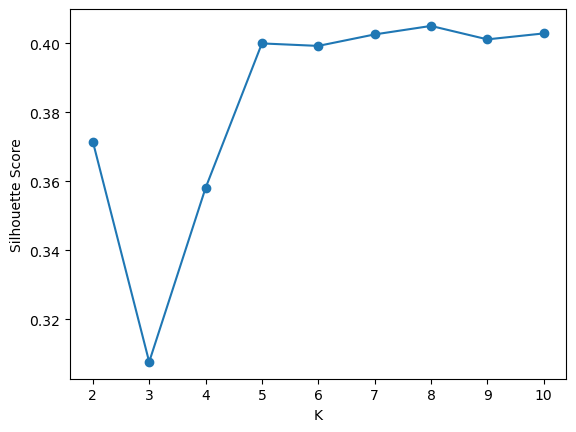

In [127]:
## 2 Silhoutte Score
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.plot(range(2,11), scores, marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
    

Text(0, 0.5, 'SS')

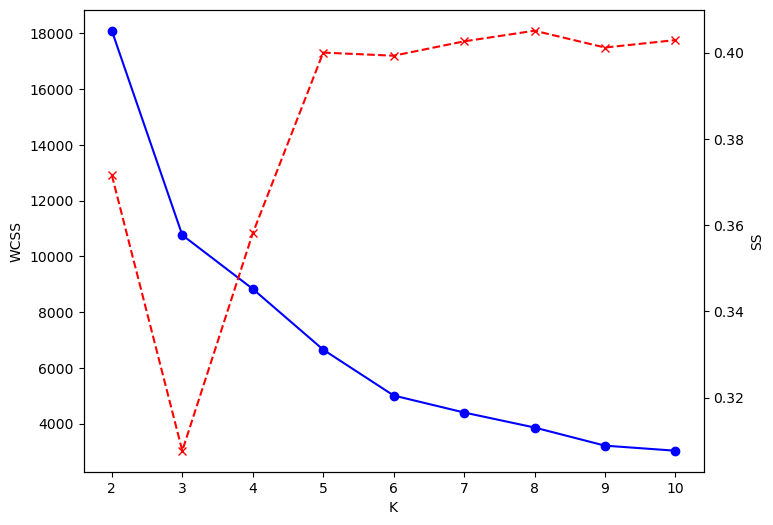

In [133]:
# Combined plot for wcss and silhoutte

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize = (8,6))
ax1.plot(k_range, wcss[:len(k_range)], marker = 'o', color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker = 'x', color = "red", linestyle = "--")
ax2.set_ylabel("SS")

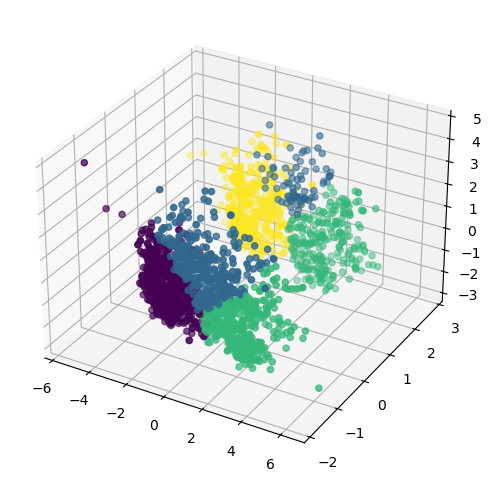

In [142]:
# Clustering K means
K = 4

kmeans = KMeans(
    n_clusters  = K,
    random_state = 42
)
labels = kmeans.fit_predict(X_pca)
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels)

In [146]:
# Agglomerative Clustering 
from sklearn.cluster import AgglomerativeClustering

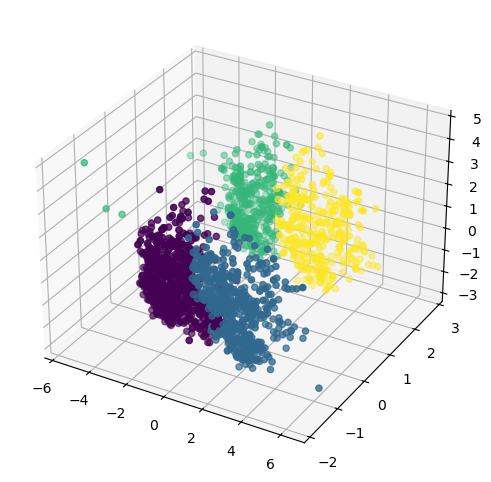

In [147]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_agg)

# Characterization of the Clusters 

In [163]:

X["cluster"] = labels_agg


In [164]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

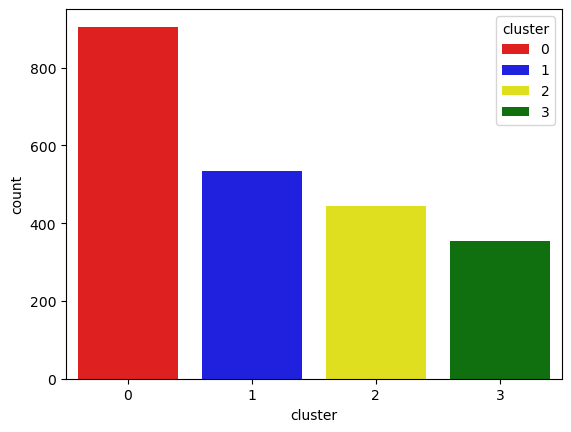

In [165]:
pal = ["red","blue","yellow","green"]
sns.countplot(x = X["cluster"], palette = pal, hue = X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

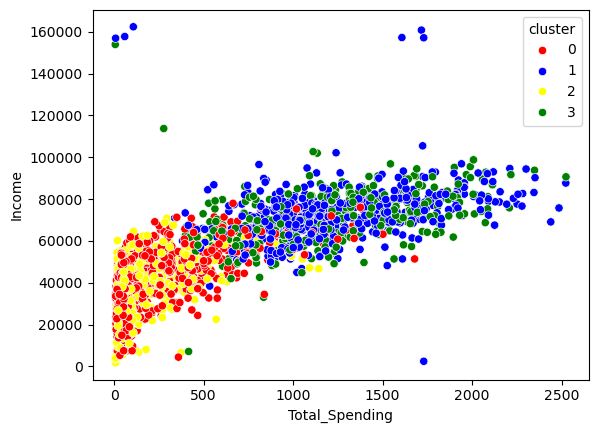

In [166]:
# Income and Spending Patterns 

sns.scatterplot(x = X["Total_Spending"], y = X["Income"], hue = X["cluster"], palette = pal)

In [167]:
# Cluster 0 -> Red Cluster (low/ moderet Income, low/moderete Spending)
# Cluster 1 -> Blue Cluster (High Income, High Spending)
# Cluster 2 -> Yellow Cluster (low Income, low Spending)
# Cluster 3 -> Green Cluster ( moderet Income, High Spending)

In [170]:
# Cluster Summary
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_days  Total_Spending  \
cluster         

In [171]:
# CO -> Family Shoppers -> Give more discount coupons to increase their bussiness 
# -More children
# - Poor Response
# - Partners
# - Website visits (more)
# - Store visits, Catpurchases (low)

# C1 -> Valued Shoppers -> Give out Loyalty programs  to increase engagement
# - Fewer children
# - Slighlty Higher Age
# - Average Response
# - Partners
# - Website visits (low)
# - Store visits, Catpurchases (more)

# C2 -> Digital Browsers -> Heavy discount coupons  
# - More children
# - Average Response
# - ALONE
# - Website visits (more)
# - Store visits, Catpurchases (low)

# C3 -> High Value Single  -> Give premium services or one to one services as they give the best ROI
# - Fewer children
# - Slighlty Higher Age
# - Best Response
# - Alone
# - Website visits (less)
# - Store visits, Catpurchases (more)